# 70 - MATLAB vs Python Normal and Adaptive Kalman

This notebook extends Notebook 69 by comparing three matched output streams on `UltraTimTrack_test.mp4`:

- MATLAB UltraTimTrack saved result;
- Python normal/fixed-R Kalman;
- Python adaptive/anisotropic-R Kalman.

Important distinction: the final output variables are matched (`Fdat.Region.FL/fas_length`, `PEN/fas_pen`, `ANG/fas_ang` versus Python `FL_mm`, `PEN_deg`, `ANG_deg`). However, matching the final variable names, ROI, and video does not automatically make the full trajectory identical, because MATLAB's saved `warp`/`awarp` affine objects are MCOS opaque objects in this `.mat` file and are not replayed byte-for-byte by SciPy. The Python framework re-computes TimTrack/KLT/aponeurosis measurements from the image sequence, then runs a MATLAB-compatible Kalman path.

To isolate the Kalman choice, this notebook runs the adaptive pipeline once with `--compare-to-fixed-kalman`. That stores adaptive outputs and fixed/normal Kalman outputs from the same Python intermediate detections.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import math
import os
import subprocess
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.io import loadmat

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

VIDEO = ROOT / 'data' / 'raw' / 'UltraTimTrack_test.mp4'
MATLAB_RESULT = ROOT / 'data' / 'matlab' / 'slow_low_01_DOWN_tracked_Q=001.mat'
ROI_PATH = ROOT / 'data' / 'rois' / 'UltraTimTrack_test_rois.json'
OUT = ROOT / 'results' / 'notebook70_matlab_normal_adaptive_kalman_comparison'
OUT.mkdir(parents=True, exist_ok=True)

UTT_EXPORT_CANDIDATES = [
    ROOT / 'data' / 'matlab' / 'UTT_numeric_export.mat',
    Path('/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat'),
]
UTT_EXPORT = next((path for path in UTT_EXPORT_CANDIDATES if path.exists()), None)

for required in [VIDEO, MATLAB_RESULT, ROI_PATH]:
    assert required.exists(), required
if UTT_EXPORT is None:
    raise FileNotFoundError('Could not find UTT_numeric_export.mat in configured candidates.')

print('ROOT:', ROOT)
print('VIDEO:', VIDEO)
print('MATLAB_RESULT:', MATLAB_RESULT)
print('ROI_PATH:', ROI_PATH)
print('UTT_EXPORT:', UTT_EXPORT)
print('OUT:', OUT)

ROOT: /Users/grosbedou/PycharmProjects/NDORMS
VIDEO: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4
MATLAB_RESULT: /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat
ROI_PATH: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json
UTT_EXPORT: /Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat
OUT: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook70_matlab_normal_adaptive_kalman_comparison


## 2. Load MATLAB Data and Audit Variables

In [2]:
cap = cv2.VideoCapture(str(VIDEO))
if not cap.isOpened():
    raise FileNotFoundError(VIDEO)
fps = float(cap.get(cv2.CAP_PROP_FPS))
n_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

mat = loadmat(MATLAB_RESULT, simplify_cells=True)
tracking = mat['TrackingData']
region = mat['Fdat']['Region']
roi_json = json.loads(ROI_PATH.read_text())

matlab_df = pd.DataFrame({
    'matlab_row': np.arange(len(np.asarray(region['FL']).reshape(-1)), dtype=int),
    'time_s': np.asarray(region['Time'], dtype=float).reshape(-1),
    'matlab_FL_mm': np.asarray(region['FL'], dtype=float).reshape(-1),
    'matlab_PEN_deg': np.asarray(region['PEN'], dtype=float).reshape(-1),
    'matlab_ANG_deg': np.asarray(region['ANG'], dtype=float).reshape(-1),
    'matlab_fas_length_mm': np.asarray(region['fas_length'], dtype=float).reshape(-1),
    'matlab_fas_pen_deg': np.asarray(region['fas_pen'], dtype=float).reshape(-1),
    'matlab_fas_ang_deg': np.asarray(region['fas_ang'], dtype=float).reshape(-1),
})

variable_audit = pd.DataFrame([
    {
        'concept': 'fascicle length',
        'MATLAB variable': 'Fdat.Region.fas_length == Fdat.Region.FL',
        'Python normal variable': 'fixed_FL_mm',
        'Python adaptive variable': 'FL_mm',
        'unit': 'mm',
        'MATLAB alias max abs diff': float(np.nanmax(np.abs(matlab_df['matlab_fas_length_mm'] - matlab_df['matlab_FL_mm']))),
    },
    {
        'concept': 'fascicle angle',
        'MATLAB variable': 'Fdat.Region.fas_ang == Fdat.Region.ANG',
        'Python normal variable': 'fixed_ANG_deg',
        'Python adaptive variable': 'ANG_deg',
        'unit': 'deg',
        'MATLAB alias max abs diff': float(np.nanmax(np.abs(matlab_df['matlab_fas_ang_deg'] - matlab_df['matlab_ANG_deg']))),
    },
    {
        'concept': 'pennation angle',
        'MATLAB variable': 'Fdat.Region.fas_pen == Fdat.Region.PEN',
        'Python normal variable': 'fixed_PEN_deg',
        'Python adaptive variable': 'PEN_deg',
        'unit': 'deg',
        'MATLAB alias max abs diff': float(np.nanmax(np.abs(matlab_df['matlab_fas_pen_deg'] - matlab_df['matlab_PEN_deg']))),
    },
])
variable_audit_path = OUT / 'variable_audit.csv'
variable_audit.to_csv(variable_audit_path, index=False)

input_metadata = pd.DataFrame([
    {'item': 'video_frames', 'value': n_video_frames},
    {'item': 'video_fps', 'value': fps},
    {'item': 'video_width_px', 'value': frame_width},
    {'item': 'video_height_px', 'value': frame_height},
    {'item': 'matlab_rows', 'value': len(matlab_df)},
    {'item': 'matlab_start_frame', 'value': tracking.get('start_frame')},
    {'item': 'matlab_NumFrames', 'value': tracking.get('NumFrames')},
    {'item': 'matlab_image_depth_mm', 'value': tracking.get('res')},
    {'item': 'roi_json', 'value': roi_json},
])
input_metadata.to_csv(OUT / 'input_metadata.csv', index=False)

display(variable_audit)
input_metadata

,concept,MATLAB variable,Python normal variable,Python adaptive variable,unit,MATLAB alias max abs diff
0,fascicle length,Fdat.Region.fas_length == Fdat.Region.FL,fixed_FL_mm,FL_mm,mm,0.0
1,fascicle angle,Fdat.Region.fas_ang == Fdat.Region.ANG,fixed_ANG_deg,ANG_deg,deg,0.0
2,pennation angle,Fdat.Region.fas_pen == Fdat.Region.PEN,fixed_PEN_deg,PEN_deg,deg,0.0


,item,value
0,video_frames,2667
1,video_fps,33.341
2,video_width_px,706
3,video_height_px,562
4,matlab_rows,2666
5,matlab_start_frame,1
6,matlab_NumFrames,2666
7,matlab_image_depth_mm,50.7
8,roi_json,"{'superficial': [20, 18, 685, 54], 'deep': [16..."


## 3. Run or Reuse Python Adaptive Pipeline with Fixed-R Reference

This is the only long-running cell. It runs the same image-derived Python framework and stores:

- adaptive/anisotropic Kalman output in `ANG_deg`, `PEN_deg`, `FL_mm`;
- normal fixed-R Kalman reference from the same intermediate detections in `fixed_ANG_deg`, `fixed_PEN_deg`, `fixed_FL_mm`;
- frame-wise confidence and adaptive `R` scale arrays.

There is no subprocess timeout in the notebook cell. If the cache is absent, let it finish.

In [3]:
PY_RUN_ROOT = OUT / 'python_adaptive_with_fixed_reference'
PY_RUN_DIR = PY_RUN_ROOT / 'UltraTimTrack_test'
PY_NPZ = PY_RUN_DIR / 'UltraTimTrack_test_strict_results.npz'
PY_CSV = PY_RUN_DIR / 'UltraTimTrack_test_strict_FL_PEN_ANG.csv'
PY_META = PY_RUN_DIR / 'UltraTimTrack_test_strict_metadata.json'
PY_COMPARISON_CSV = PY_RUN_DIR / 'UltraTimTrack_test_kalman_comparison_vs_fixed.csv'

FORCE_RERUN_PYTHON = False

python_cmd = [
    sys.executable,
    str(ROOT / 'scripts' / 'run_ultratimtrack_adaptive_confidence.py'),
    str(VIDEO),
    '--roi-path', str(ROI_PATH),
    '--utt-export', str(UTT_EXPORT),
    '--results-dir', str(PY_RUN_ROOT),
    '--seed-frames', '11',
    '--apo-maxangle', '10',
    '--candidate-persistence',
    '--apo-gating',
    '--kalman-mode', 'adaptive-anisotropic',
    '--compare-to-fixed-kalman',
    '--save-confidence-plots',
    '--no-annotated-video',
    '--save-overlays', '2',
    '--no-time-series-plot',
    '--progress-every', '250',
]

if FORCE_RERUN_PYTHON or not PY_NPZ.exists():
    print('Running Python adaptive framework with fixed-R comparison:')
    print(' '.join(python_cmd))
    env = dict(os.environ)
    env.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
    started = time.time()
    completed = subprocess.run(python_cmd, cwd=ROOT, text=True, env=env)
    elapsed = time.time() - started
    print(f'Python run elapsed: {elapsed:.1f} s')
    if completed.returncode != 0:
        raise RuntimeError(f'Python adaptive framework run failed with return code {completed.returncode}')
else:
    print('Using cached Python adaptive framework result:', PY_NPZ)

for produced in [PY_NPZ, PY_CSV, PY_META, PY_COMPARISON_CSV]:
    assert produced.exists(), produced

print('PY_NPZ:', PY_NPZ)
print('PY_CSV:', PY_CSV)
print('PY_META:', PY_META)
print('PY_COMPARISON_CSV:', PY_COMPARISON_CSV)

Running Python adaptive framework with fixed-R comparison:
/Users/grosbedou/PycharmProjects/NDORMS/.venv/bin/python /Users/grosbedou/PycharmProjects/NDORMS/scripts/run_ultratimtrack_adaptive_confidence.py /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 --roi-path /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json --utt-export /Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat --results-dir /Users/grosbedou/PycharmProjects/NDORMS/results/notebook70_matlab_normal_adaptive_kalman_comparison/python_adaptive_with_fixed_reference --seed-frames 11 --apo-maxangle 10 --candidate-persistence --apo-gating --kalman-mode adaptive-anisotropic --compare-to-fixed-kalman --save-confidence-plots --no-annotated-video --save-overlays 2 --no-time-series-plot --progress-every 250


Loading ROIs: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json

Running TimTrack image stream...
TimTrack image geofeatures processed 250
TimTrack image geofeatures processed 500
TimTrack image geofeatures processed 750
TimTrack image geofeatures processed 1000
TimTrack image geofeatures processed 1250
TimTrack image geofeatures processed 1500
TimTrack image geofeatures processed 1750
TimTrack image geofeatures processed 2000
TimTrack image geofeatures processed 2250
TimTrack image geofeatures processed 2500

Selecting autonomous fascicle seed...
Selected seed alpha: 17.500 deg (a17.50_x350_l75)

Estimating fascicle KLT affines...
one-step KLT processed 251/2667
one-step KLT processed 501/2667
one-step KLT processed 751/2667
one-step KLT processed 1001/2667
one-step KLT processed 1251/2667
one-step KLT processed 1501/2667
one-step KLT processed 1751/2667
one-step KLT processed 2001/2667
one-step KLT processed 2251/2667
one-step KLT processed 2501/2667
one-

## 4. Align MATLAB, Python Normal, and Python Adaptive

In [4]:
def load_npz(path: Path) -> dict[str, np.ndarray]:
    with np.load(path, allow_pickle=True) as data:
        return {key: data[key] for key in data.files}

py = load_npz(PY_NPZ)
py_meta = json.loads(PY_META.read_text())

required_python_keys = [
    'frame', 'time_s',
    'fixed_FL_mm', 'fixed_PEN_deg', 'fixed_ANG_deg',
    'FL_mm', 'PEN_deg', 'ANG_deg',
    'combined_confidence', 'r_scale', 'r_scale_theta', 'r_scale_length',
]
missing = [key for key in required_python_keys if key not in py]
if missing:
    raise KeyError(f'Missing expected Python arrays: {missing}')

py_time = np.asarray(py['time_s'], dtype=float).reshape(-1)
mat_time = matlab_df['time_s'].to_numpy(dtype=float)

offset_scores = []
for offset in range(0, min(5, max(1, len(py_time) - len(mat_time) + 3))):
    n = min(len(mat_time), len(py_time) - offset)
    if n <= 10:
        continue
    sample = min(n, 250)
    score = float(np.nanmedian(np.abs(py_time[offset:offset + sample] - mat_time[:sample])))
    offset_scores.append({'python_offset': offset, 'median_abs_time_error_s_first250': score, 'n_overlap': n})
offset_table = pd.DataFrame(offset_scores)
PYTHON_OFFSET = int(offset_table.sort_values('median_abs_time_error_s_first250').iloc[0]['python_offset'])
N = int(min(len(matlab_df), len(py_time) - PYTHON_OFFSET))

aligned = pd.DataFrame({
    'matlab_row': matlab_df['matlab_row'].iloc[:N].to_numpy(dtype=int),
    'python_frame': np.asarray(py['frame'], dtype=int).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'time_s': mat_time[:N],
    'python_time_s': py_time[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'matlab_FL_mm': matlab_df['matlab_fas_length_mm'].iloc[:N].to_numpy(dtype=float),
    'matlab_ANG_deg': matlab_df['matlab_fas_ang_deg'].iloc[:N].to_numpy(dtype=float),
    'matlab_PEN_deg': matlab_df['matlab_fas_pen_deg'].iloc[:N].to_numpy(dtype=float),
    'python_normal_FL_mm': np.asarray(py['fixed_FL_mm'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'python_normal_ANG_deg': np.asarray(py['fixed_ANG_deg'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'python_normal_PEN_deg': np.asarray(py['fixed_PEN_deg'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'python_adaptive_FL_mm': np.asarray(py['FL_mm'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'python_adaptive_ANG_deg': np.asarray(py['ANG_deg'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'python_adaptive_PEN_deg': np.asarray(py['PEN_deg'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'combined_confidence': np.asarray(py['combined_confidence'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'r_scale': np.asarray(py['r_scale'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'r_scale_theta': np.asarray(py['r_scale_theta'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
    'r_scale_length': np.asarray(py['r_scale_length'], dtype=float).reshape(-1)[PYTHON_OFFSET:PYTHON_OFFSET + N],
})

for method in ['normal', 'adaptive']:
    for variable in ['FL_mm', 'ANG_deg', 'PEN_deg']:
        aligned[f'delta_{method}_{variable}'] = aligned[f'python_{method}_{variable}'] - aligned[f'matlab_{variable}']

for variable in ['FL_mm', 'ANG_deg', 'PEN_deg']:
    aligned[f'delta_adaptive_minus_normal_{variable}'] = aligned[f'python_adaptive_{variable}'] - aligned[f'python_normal_{variable}']

aligned_path = OUT / 'aligned_matlab_python_normal_adaptive_outputs.csv'
aligned.to_csv(aligned_path, index=False)

display(offset_table)
print('Selected Python offset:', PYTHON_OFFSET)
print('Aligned rows:', len(aligned))
print('Saved:', aligned_path)
aligned.head()

,python_offset,median_abs_time_error_s_first250,n_overlap
0,0,0.029992,2666
1,1,0.000001,2666
2,2,0.029994,2665
3,3,0.059987,2664


Selected Python offset: 1
Aligned rows: 2666
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook70_matlab_normal_adaptive_kalman_comparison/aligned_matlab_python_normal_adaptive_outputs.csv


,matlab_row,python_frame,time_s,python_time_s,matlab_FL_mm,matlab_ANG_deg,matlab_PEN_deg,python_normal_FL_mm,python_normal_ANG_deg,python_normal_PEN_deg,...,r_scale_length,delta_normal_FL_mm,delta_normal_ANG_deg,delta_normal_PEN_deg,delta_adaptive_FL_mm,delta_adaptive_ANG_deg,delta_adaptive_PEN_deg,delta_adaptive_minus_normal_FL_mm,delta_adaptive_minus_normal_ANG_deg,delta_adaptive_minus_normal_PEN_deg
0,0,1,0.029993,0.029993,72.307050,18.520489,20.387454,75.828046,17.500006,19.329085,...,0.500000,3.520995,-1.020483,-1.058369,3.520995,-1.020483,-1.058369,3.850940e-08,0.000000,0.000000
1,1,2,0.059986,0.059986,72.304143,18.520433,20.388172,75.827583,17.499419,19.329326,...,0.504501,3.523440,-1.021015,-1.058846,3.523440,-1.021015,-1.058846,5.376826e-08,0.000000,0.000000
2,2,3,0.089979,0.089979,72.303613,18.519920,20.388371,75.835206,17.495753,19.327615,...,0.501746,3.531593,-1.024167,-1.060756,3.531593,-1.024167,-1.060756,2.161146e-07,0.000000,0.000000
3,3,4,0.119972,0.119972,72.306344,18.517583,20.387863,75.845018,17.492056,19.325189,...,0.500025,3.538674,-1.025526,-1.062674,3.538674,-1.025526,-1.062674,3.768291e-07,0.000000,0.000000
4,4,5,0.149965,0.149966,72.312694,18.514817,20.386084,75.859797,17.486791,19.320951,...,0.501701,3.547102,-1.028026,-1.065133,3.547075,-1.028019,-1.065126,-2.701698e-05,0.000007,0.000007


## 5. Agreement and Equivalence Statistics

In [5]:
ALPHA = 0.05
EQ_BOUNDS = {
    'FL_mm': 5.0,
    'ANG_deg': 5.0,
    'PEN_deg': 5.0,
}
BOOTSTRAP_REPLICATES = 2000
BLOCK_LENGTH_FRAMES = max(5, int(round(float(fps))))
RNG_SEED = 70


def finite_pair(reference: np.ndarray, estimate: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    ref = np.asarray(reference, dtype=float).reshape(-1)
    est = np.asarray(estimate, dtype=float).reshape(-1)
    n = min(len(ref), len(est))
    ref = ref[:n]
    est = est[:n]
    mask = np.isfinite(ref) & np.isfinite(est)
    return ref[mask], est[mask]


def lins_ccc(reference: np.ndarray, estimate: np.ndarray) -> float:
    ref, est = finite_pair(reference, estimate)
    if len(ref) < 2:
        return np.nan
    mean_ref = np.mean(ref)
    mean_est = np.mean(est)
    var_ref = np.var(ref, ddof=1)
    var_est = np.var(est, ddof=1)
    cov = np.cov(ref, est, ddof=1)[0, 1]
    denom = var_ref + var_est + (mean_ref - mean_est) ** 2
    return float((2 * cov) / denom) if denom > 0 else np.nan


def tost_pvalue(diff: np.ndarray, bound: float) -> float:
    diff = np.asarray(diff, dtype=float)
    diff = diff[np.isfinite(diff)]
    n = len(diff)
    if n < 2:
        return np.nan
    mean = float(np.mean(diff))
    sd = float(np.std(diff, ddof=1))
    if sd == 0:
        return 0.0 if abs(mean) < bound else 1.0
    se = sd / math.sqrt(n)
    df = n - 1
    lower = -float(bound)
    upper = float(bound)
    p_lower = 1.0 - stats.t.cdf((mean - lower) / se, df=df)
    p_upper = stats.t.cdf((mean - upper) / se, df=df)
    return float(max(p_lower, p_upper))


def moving_block_bootstrap_mean_ci(diff, *, block_length: int, n_bootstrap: int, alpha: float, seed: int) -> tuple[float, float]:
    diff = np.asarray(diff, dtype=float)
    diff = diff[np.isfinite(diff)]
    n = len(diff)
    if n == 0:
        return np.nan, np.nan
    block_length = max(1, min(int(block_length), n))
    n_blocks = int(math.ceil(n / block_length))
    max_start = n - block_length
    rng = np.random.default_rng(seed)
    means = np.empty(int(n_bootstrap), dtype=float)
    for idx in range(int(n_bootstrap)):
        starts = rng.integers(0, max_start + 1, size=n_blocks)
        sample = np.concatenate([diff[start:start + block_length] for start in starts])[:n]
        means[idx] = np.mean(sample)
    return tuple(np.quantile(means, [alpha / 2.0, 1.0 - alpha / 2.0]).astype(float))


def agreement_row(method: str, variable: str, unit: str, reference: np.ndarray, estimate: np.ndarray) -> dict[str, float | str | bool | int]:
    ref, est = finite_pair(reference, estimate)
    diff = est - ref
    n = len(diff)
    bound = EQ_BOUNDS[variable]
    mean_diff = float(np.mean(diff)) if n else np.nan
    sd_diff = float(np.std(diff, ddof=1)) if n > 1 else np.nan
    se = sd_diff / math.sqrt(n) if n > 1 else np.nan
    tcrit = float(stats.t.ppf(1.0 - ALPHA / 2.0, df=n - 1)) if n > 1 else np.nan
    ci_low = mean_diff - tcrit * se if n > 1 else np.nan
    ci_high = mean_diff + tcrit * se if n > 1 else np.nan
    block_low, block_high = moving_block_bootstrap_mean_ci(
        diff,
        block_length=BLOCK_LENGTH_FRAMES,
        n_bootstrap=BOOTSTRAP_REPLICATES,
        alpha=ALPHA,
        seed=RNG_SEED + len(method) + len(variable),
    )
    corr = float(np.corrcoef(ref, est)[0, 1]) if n > 1 and np.std(ref) > 0 and np.std(est) > 0 else np.nan
    p_tost = tost_pvalue(diff, bound)
    return {
        'method': method,
        'variable': variable,
        'unit': unit,
        'n': int(n),
        'matlab_mean': float(np.mean(ref)) if n else np.nan,
        'python_mean': float(np.mean(est)) if n else np.nan,
        'bias_python_minus_matlab': mean_diff,
        'bias_95ci_low_framewise': ci_low,
        'bias_95ci_high_framewise': ci_high,
        'bias_95ci_low_block_bootstrap': block_low,
        'bias_95ci_high_block_bootstrap': block_high,
        'mae': float(np.mean(np.abs(diff))) if n else np.nan,
        'rmse': float(np.sqrt(np.mean(diff ** 2))) if n else np.nan,
        'sd_diff': sd_diff,
        'max_abs_diff': float(np.max(np.abs(diff))) if n else np.nan,
        'pearson_r': corr,
        'lins_ccc': lins_ccc(ref, est),
        'equivalence_margin': bound,
        'tost_pvalue_framewise': p_tost,
        'equivalent_by_framewise_tost': bool(np.isfinite(p_tost) and p_tost < ALPHA and ci_low > -bound and ci_high < bound),
        'equivalent_by_block_bootstrap_ci': bool(block_low > -bound and block_high < bound),
    }

rows = []
for method in ['normal', 'adaptive']:
    rows.extend([
        agreement_row(method, 'FL_mm', 'mm', aligned['matlab_FL_mm'], aligned[f'python_{method}_FL_mm']),
        agreement_row(method, 'ANG_deg', 'deg', aligned['matlab_ANG_deg'], aligned[f'python_{method}_ANG_deg']),
        agreement_row(method, 'PEN_deg', 'deg', aligned['matlab_PEN_deg'], aligned[f'python_{method}_PEN_deg']),
    ])

stats_df = pd.DataFrame(rows)
stats_path = OUT / 'matlab_python_normal_adaptive_equivalence_statistics.csv'
stats_df.to_csv(stats_path, index=False)
print('Saved:', stats_path)
stats_df

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook70_matlab_normal_adaptive_kalman_comparison/matlab_python_normal_adaptive_equivalence_statistics.csv


,method,variable,unit,n,matlab_mean,python_mean,bias_python_minus_matlab,bias_95ci_low_framewise,bias_95ci_high_framewise,bias_95ci_low_block_bootstrap,...,mae,rmse,sd_diff,max_abs_diff,pearson_r,lins_ccc,equivalence_margin,tost_pvalue_framewise,equivalent_by_framewise_tost,equivalent_by_block_bootstrap_ci
0,normal,FL_mm,mm,2666,55.215216,53.120402,-2.094814,-2.169165,-2.020463,-2.565706,...,2.412748,2.867034,1.957824,6.282391,0.978291,0.954566,5.0,0.0,True,True
1,normal,ANG_deg,deg,2666,25.526129,26.718270,1.192141,1.151650,1.232632,0.995969,...,1.321171,1.599246,1.066215,4.697785,0.980172,0.946790,5.0,0.0,True,True
2,normal,PEN_deg,deg,2666,26.958866,28.068303,1.109437,1.069723,1.149151,0.916643,...,1.261089,1.524474,1.045744,4.450124,0.977580,0.945172,5.0,0.0,True,True
3,adaptive,FL_mm,mm,2666,55.215216,53.044577,-2.170639,-2.242860,-2.098418,-2.613850,...,2.416541,2.885628,1.901719,6.449644,0.979458,0.953914,5.0,0.0,True,True
4,adaptive,ANG_deg,deg,2666,25.526129,26.756415,1.230285,1.191394,1.269177,1.050253,...,1.326267,1.600611,1.024083,4.664731,0.981829,0.946687,5.0,0.0,True,True
5,adaptive,PEN_deg,deg,2666,26.958866,28.106447,1.147581,1.109485,1.185677,0.969614,...,1.256462,1.524096,1.003146,4.417070,0.979407,0.945160,5.0,0.0,True,True


## 6. Adaptive Minus Normal Summary

In [6]:
def delta_summary(variable: str, unit: str) -> dict[str, float | str | int]:
    delta = aligned[f'delta_adaptive_minus_normal_{variable}'].to_numpy(dtype=float)
    delta = delta[np.isfinite(delta)]
    return {
        'variable': variable,
        'unit': unit,
        'n': int(len(delta)),
        'mean_adaptive_minus_normal': float(np.mean(delta)),
        'median_adaptive_minus_normal': float(np.median(delta)),
        'mae_adaptive_minus_normal': float(np.mean(np.abs(delta))),
        'rmse_adaptive_minus_normal': float(np.sqrt(np.mean(delta ** 2))),
        'max_abs_adaptive_minus_normal': float(np.max(np.abs(delta))),
    }

adaptive_minus_normal = pd.DataFrame([
    delta_summary('FL_mm', 'mm'),
    delta_summary('ANG_deg', 'deg'),
    delta_summary('PEN_deg', 'deg'),
])
adaptive_minus_normal_path = OUT / 'adaptive_minus_normal_summary.csv'
adaptive_minus_normal.to_csv(adaptive_minus_normal_path, index=False)

confidence_summary = pd.DataFrame([{
    'combined_confidence_median': float(np.nanmedian(aligned['combined_confidence'])),
    'combined_confidence_min': float(np.nanmin(aligned['combined_confidence'])),
    'r_scale_median': float(np.nanmedian(aligned['r_scale'])),
    'r_scale_max': float(np.nanmax(aligned['r_scale'])),
    'r_scale_theta_median': float(np.nanmedian(aligned['r_scale_theta'])),
    'r_scale_theta_max': float(np.nanmax(aligned['r_scale_theta'])),
    'r_scale_length_median': float(np.nanmedian(aligned['r_scale_length'])),
    'r_scale_length_max': float(np.nanmax(aligned['r_scale_length'])),
}])
confidence_summary_path = OUT / 'adaptive_confidence_summary.csv'
confidence_summary.to_csv(confidence_summary_path, index=False)

display(adaptive_minus_normal)
confidence_summary

,variable,unit,n,mean_adaptive_minus_normal,median_adaptive_minus_normal,mae_adaptive_minus_normal,rmse_adaptive_minus_normal,max_abs_adaptive_minus_normal
0,FL_mm,mm,2666,-0.075825,-0.026161,0.108387,0.152974,0.408535
1,ANG_deg,deg,2666,0.038144,0.015203,0.058834,0.081265,0.223225
2,PEN_deg,deg,2666,0.038144,0.015203,0.058834,0.081265,0.223225


,combined_confidence_median,combined_confidence_min,r_scale_median,r_scale_max,r_scale_theta_median,r_scale_theta_max,r_scale_length_median,r_scale_length_max
0,0.963465,0.701283,0.636173,3.683638,0.716237,3.086886,0.508476,0.729961


## 7. Plot Length and Angle for All Three Methods

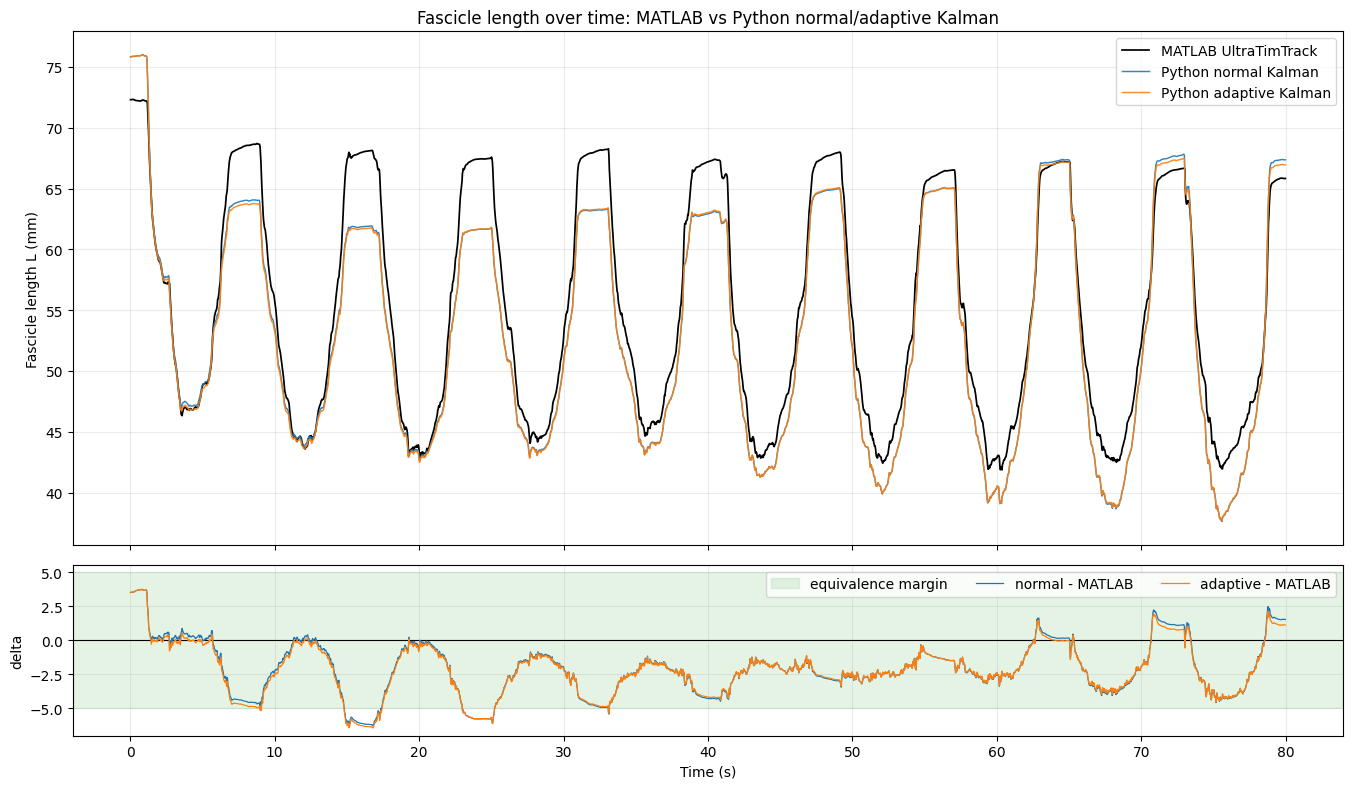

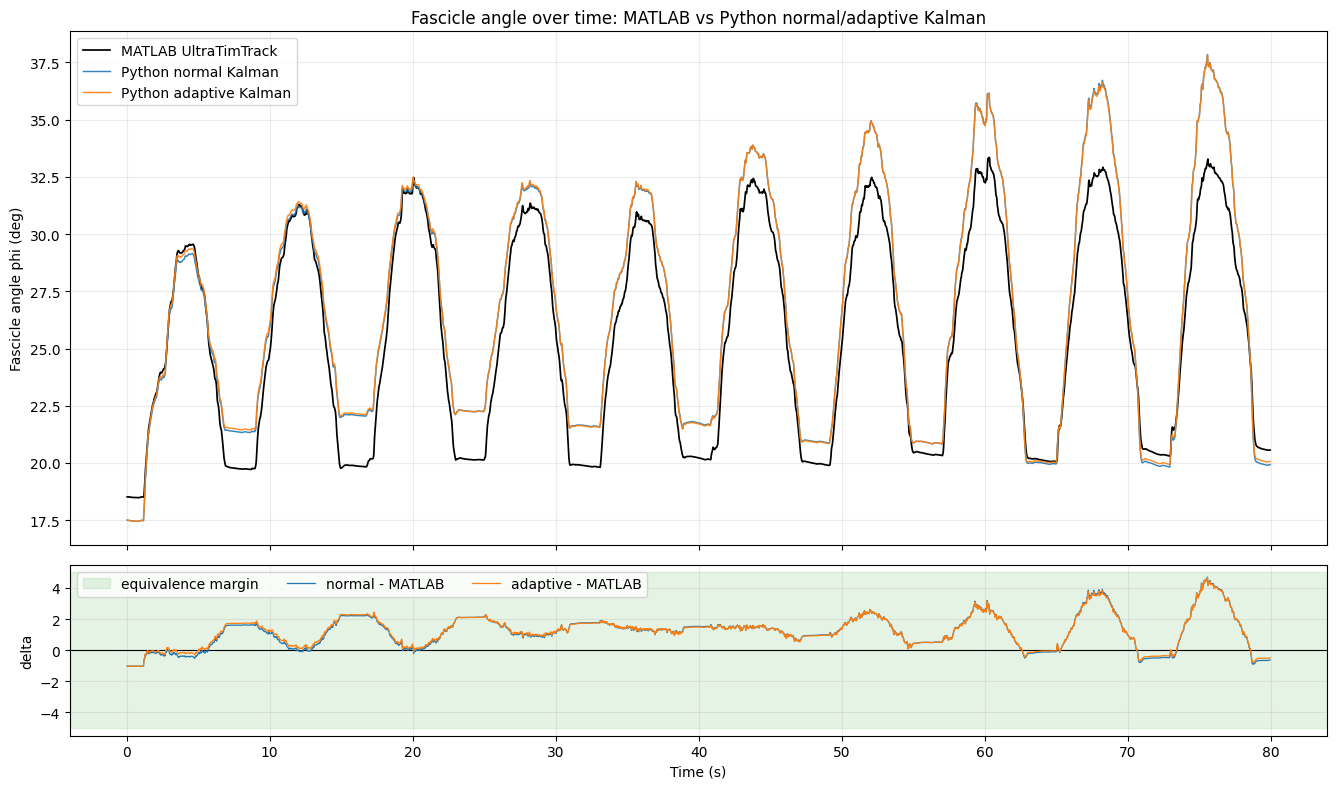

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook70_matlab_normal_adaptive_kalman_comparison/fascicle_length_matlab_python_normal_adaptive_over_time.png
Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook70_matlab_normal_adaptive_kalman_comparison/fascicle_angle_matlab_python_normal_adaptive_over_time.png


In [7]:
def plot_three_way(variable: str, ylabel: str, title: str, output_name: str, *, equivalence_bound: float) -> Path:
    t = aligned['time_s'].to_numpy(dtype=float)
    fig, axes = plt.subplots(2, 1, figsize=(13.5, 8.0), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    axes[0].plot(t, aligned[f'matlab_{variable}'], color='black', linewidth=1.25, label='MATLAB UltraTimTrack')
    axes[0].plot(t, aligned[f'python_normal_{variable}'], color='tab:blue', linewidth=1.05, alpha=0.9, label='Python normal Kalman')
    axes[0].plot(t, aligned[f'python_adaptive_{variable}'], color='tab:orange', linewidth=1.05, alpha=0.9, label='Python adaptive Kalman')
    axes[0].set_ylabel(ylabel)
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(loc='best')
    axes[0].set_title(title)

    axes[1].axhspan(-equivalence_bound, equivalence_bound, color='tab:green', alpha=0.12, label='equivalence margin')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].plot(t, aligned[f'delta_normal_{variable}'], color='tab:blue', linewidth=0.9, label='normal - MATLAB')
    axes[1].plot(t, aligned[f'delta_adaptive_{variable}'], color='tab:orange', linewidth=0.9, label='adaptive - MATLAB')
    axes[1].set_ylabel('delta')
    axes[1].set_xlabel('Time (s)')
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(loc='best', ncol=3)

    fig.tight_layout()
    out_path = OUT / output_name
    fig.savefig(out_path, dpi=180)
    plt.show()
    return out_path

length_plot = plot_three_way(
    'FL_mm',
    'Fascicle length L (mm)',
    'Fascicle length over time: MATLAB vs Python normal/adaptive Kalman',
    'fascicle_length_matlab_python_normal_adaptive_over_time.png',
    equivalence_bound=EQ_BOUNDS['FL_mm'],
)
angle_plot = plot_three_way(
    'ANG_deg',
    'Fascicle angle phi (deg)',
    'Fascicle angle over time: MATLAB vs Python normal/adaptive Kalman',
    'fascicle_angle_matlab_python_normal_adaptive_over_time.png',
    equivalence_bound=EQ_BOUNDS['ANG_deg'],
)
print('Saved:', length_plot)
print('Saved:', angle_plot)

## 8. Article-Ready Table and Interpretation

In [8]:
article_summary = stats_df[[
    'method',
    'variable',
    'unit',
    'n',
    'matlab_mean',
    'python_mean',
    'bias_python_minus_matlab',
    'bias_95ci_low_block_bootstrap',
    'bias_95ci_high_block_bootstrap',
    'mae',
    'rmse',
    'pearson_r',
    'lins_ccc',
    'equivalence_margin',
    'equivalent_by_block_bootstrap_ci',
]].copy()
article_summary_path = OUT / 'article_ready_normal_adaptive_summary_table.csv'
article_summary.to_csv(article_summary_path, index=False)

primary = stats_df[stats_df['variable'].isin(['FL_mm', 'ANG_deg'])]
passes = primary.groupby('method')['equivalent_by_block_bootstrap_ci'].all().to_dict()

lines = [
    '# Notebook 70 MATLAB vs Python normal/adaptive Kalman summary',
    '',
    f'Compared {len(aligned)} matched frames from `{VIDEO.name}`.',
    f'MATLAB rows were aligned to Python/video frames using Python offset {PYTHON_OFFSET}.',
    'Final variables are matched: MATLAB `FL/fas_length`, `ANG/fas_ang`, `PEN/fas_pen` versus Python `FL_mm`, `ANG_deg`, `PEN_deg`.',
    'Normal and adaptive Python series come from the same Python intermediate detections; only Kalman measurement covariance differs.',
    '',
]
for method in ['normal', 'adaptive']:
    verdict = 'met' if passes.get(method, False) else 'did not meet'
    lines.append(f'Python {method} Kalman {verdict} the pre-specified mean-equivalence criterion for both primary endpoints.')
    method_rows = stats_df[(stats_df['method'] == method) & (stats_df['variable'].isin(['FL_mm', 'ANG_deg']))]
    for _, row in method_rows.iterrows():
        lines.append(
            f"- {row['variable']}: bias {row['bias_python_minus_matlab']:.3f} {row['unit']} "
            f"(block-bootstrap 95% CI {row['bias_95ci_low_block_bootstrap']:.3f} to {row['bias_95ci_high_block_bootstrap']:.3f}), "
            f"RMSE {row['rmse']:.3f}, CCC {row['lins_ccc']:.3f}."
        )
    lines.append('')

lines.extend([
    f'Adaptive-minus-normal summary CSV: `{adaptive_minus_normal_path}`',
    f'Adaptive confidence summary CSV: `{confidence_summary_path}`',
    f'Length plot: `{length_plot}`',
    f'Angle plot: `{angle_plot}`',
    f'Aligned data CSV: `{aligned_path}`',
    f'Statistics CSV: `{stats_path}`',
])
summary_text = '\n'.join(lines)
summary_path = OUT / 'notebook70_normal_adaptive_summary.md'
summary_path.write_text(summary_text, encoding='utf-8')
print(summary_text)
print('\nSaved:', summary_path)
article_summary

# Notebook 70 MATLAB vs Python normal/adaptive Kalman summary

Compared 2666 matched frames from `UltraTimTrack_test.mp4`.
MATLAB rows were aligned to Python/video frames using Python offset 1.
Final variables are matched: MATLAB `FL/fas_length`, `ANG/fas_ang`, `PEN/fas_pen` versus Python `FL_mm`, `ANG_deg`, `PEN_deg`.
Normal and adaptive Python series come from the same Python intermediate detections; only Kalman measurement covariance differs.

Python normal Kalman met the pre-specified mean-equivalence criterion for both primary endpoints.
- FL_mm: bias -2.095 mm (block-bootstrap 95% CI -2.566 to -1.761), RMSE 2.867, CCC 0.955.
- ANG_deg: bias 1.192 deg (block-bootstrap 95% CI 0.996 to 1.444), RMSE 1.599, CCC 0.947.

Python adaptive Kalman met the pre-specified mean-equivalence criterion for both primary endpoints.
- FL_mm: bias -2.171 mm (block-bootstrap 95% CI -2.614 to -1.832), RMSE 2.886, CCC 0.954.
- ANG_deg: bias 1.230 deg (block-bootstrap 95% CI 1.050 to 1.462), RMSE 1.601, C

,method,variable,unit,n,matlab_mean,python_mean,bias_python_minus_matlab,bias_95ci_low_block_bootstrap,bias_95ci_high_block_bootstrap,mae,rmse,pearson_r,lins_ccc,equivalence_margin,equivalent_by_block_bootstrap_ci
0,normal,FL_mm,mm,2666,55.215216,53.120402,-2.094814,-2.565706,-1.761177,2.412748,2.867034,0.978291,0.954566,5.0,True
1,normal,ANG_deg,deg,2666,25.526129,26.718270,1.192141,0.995969,1.443821,1.321171,1.599246,0.980172,0.946790,5.0,True
2,normal,PEN_deg,deg,2666,26.958866,28.068303,1.109437,0.916643,1.349124,1.261089,1.524474,0.977580,0.945172,5.0,True
3,adaptive,FL_mm,mm,2666,55.215216,53.044577,-2.170639,-2.613850,-1.831531,2.416541,2.885628,0.979458,0.953914,5.0,True
4,adaptive,ANG_deg,deg,2666,25.526129,26.756415,1.230285,1.050253,1.461826,1.326267,1.600611,0.981829,0.946687,5.0,True
5,adaptive,PEN_deg,deg,2666,26.958866,28.106447,1.147581,0.969614,1.374105,1.256462,1.524096,0.979407,0.945160,5.0,True
